The Quantum Approximate Optimization Algorithm (QAOA)for Weighted & Un-weighted Max-Cut Problems 

In [1]:
# Import necessary libraries 
import numpy as np 
import itertools 
import scipy.linalg as la
from collections import Counter 

In [ ]:
# Basic functions for QAOA Implementation of the Max-Cut Problem 

# Make basic pauli matrices as global variables 
X = np.array([[0, 1], [1,0]])
Z = np.array([[1, 0], [0, -1]])
I = np.array([[1, 0], [0, 1]]) 

# Calculates the Kronecker product for a list of operators 
# combines single-qubit operators into a big matrix that acts on all qubits 
def kron_n(operators): 
    result = operators[0]
    for operator in operators[1:]: 
        result = np.kron(result, operator)
    return result 

# Builds the cost hamiltonian for the non-weighted Max-Cut using the formula 
def create_UW_hamiltonian(adjacency_matrix):
    num_vertices = len(adjacency_matrix)
    dim = 2 ** num_vertices # dimension of quantum state space 

    # initialize the main hamiltonian that encodes this specific problem
    hamiltonian = np.zeros((dim, dim)) 

    # iterates over the edges (i, j) & only looks at an edge once 
    for i in range(num_vertices): 
        for j in range(i + 1, num_vertices):
            # only adds edges that exist in the graph (so not 0)
            if adjacency_matrix[i][j] != 0:
                operators = [I] * num_vertices # operator list 
                operators[i] = Z # operator for vertex i 
                operators[j] = Z # operator for vertex j 

                # creates the term for this edge and adds to the hamiltonian 
                # the term gives 1 if the bits are different (edge is cut) and 0 if same (not cut)
                Z_ij = kron_n(operators)
                hamiltonian += 0.5 * (np.eye(dim) - Z_ij) # np.eye(dim) is the identity matrix scaled
    return hamiltonian

# Makes the mixer hamiltonian using the formula 
def create_mixer_hamiltonian(num_vertices): 
    hamiltonian = np.zeros((2 ** num_vertices, 2 ** num_vertices))

    # iterates over each edge and adds the corresponding term to the mixer 
    for i in range(num_vertices):
        operators = [I] * num_vertices 
        # X gate flips each bit independently 
        operators[i] = X
        hamiltonian += kron_n(operators)
    return hamiltonian

# Prepares the QAOA state by applying the cost and mixer hamiltonians with the corresponding optimized parameters 
def qaoa_state(H_cost, H_mixer, gammas, betas): 
    # intitializes the state in equal superposition of all bitstrings 
    num_vertices = int(np.log2(H_cost.shape[0]))
    psi = np.ones(2**num_vertices) / np.sqrt(2 ** num_vertices)

    # applies layers of the QAOA by alternating between the cost and mixer hamiltoniains 
    # with the corresponding parameters from optimization 
    for gamma, beta in zip(gammas, betas): 
        # makes unitary operators for the cost and mixer hamiltonians using matrix exponentiation 
        U_cost = la.expm(-1j * gamma * H_cost)
        U_mixer = la.expm(-1j * beta * H_mixer) 
        
        # cost unitary applies a phase based on the cut value to amplify good cuts and surpress bad cuts 
        psi = U_cost @ psi 
        # mixer unitar creates superposition and allows exploring of different bitstrings 
        psi = U_mixer @ psi
    return psi

# Calculates the average energy of the quantum state by taking the expectation value of the cost hamiltonian 
def expectation(psi, H): 
    return - np.real(np.conj(psi) @ (H @ psi)) # negative since minimizing 

# Samples bitstrings from the probability density of the quantum state 
def sample_bitstrings(psi, shots=1000): 
    probabilities = np.abs(psi) ** 2 
    n = int(np.log2(len(psi))) 

    # measures the state mutiple times to get a distribution of bitstrings 
    indexes = np.random.choice(len(probabilities), size=shots, p=probabilities)
    # converts the indexes to bitstrings in tuple form 
    bitstrings = [tuple(int(b) for b in format(i, f"0{n}b")) for i in indexes]
    return bitstrings 

# Calculates the cut value for a given bitstring and adjacency matrix by counting how many edges are cut 
def cut_value(bitstring, adjacency_matrix): 
    value = 0 
    num_vertices = len(bitstring) 

    # iterates over all edges once and counts how many edges are cut 
    for i in range(num_vertices): 
        for j in range(i + 1, num_vertices): 
            if adjacency_matrix[i][j] != 0: 
                if bitstring[i] != bitstring[j]: 
                    value += 1
    # returns cut value for this bitstring
    return value 


# Optimizes the QAOA parameters by randomly sampling and updating the best energy 
# note: p is the number of layers in the QAOA 
def optimize_qaoa(H_cost, H_mixer, p, trials=1000): 
    # intializes the best energy to infinity and best parameters to None 
    best_energy = float('inf')
    best_params = None 

    for trial in range(trials): 
        # initialize random parameters for the QAOA layers 
        gammas = np.random.uniform(0, np.pi, p)
        betas = np.random.uniform(0, np.pi, p)

        # run QAOA with these parameters and evaluate the energy of the resulting state 
        psi = qaoa_state(H_cost, H_mixer, gammas, betas)
        energy = expectation(psi, H_cost)

        # minimizing the energy maximizes the cut value so updates the best parameters if best energy 
        if energy < best_energy:
            best_energy = energy
            best_params = (gammas, betas)

    # returns (gammas, beta) and the best energy found from QAOA 
    return best_params, best_energy


In [39]:
# Brute force method for the Unweighted Max-Cut 

# iterates through all possible bitstrings and calculates the cut value for each to find the max cut value 
# with more vertices(n), this becomes difficult due to exponential growth of possible solutions (2^n)
def brute_force_maxcut(adjacency_matrix): 
    num_vertices = len(adjacency_matrix)
    best_solutions = []
    best_cut = -1

    # iterates through all possible bitstrings that have the name number of vertices 
    for bitstring in itertools.product([0, 1], repeat=num_vertices): 
        # calculate cut values for each bitstring and updates the best solutions & cut value
        value = cut_value(bitstring, adjacency_matrix)

        if value > best_cut:
            best_cut = value
            best_solutions = [bitstring]   # reset list
        elif value == best_cut:
            best_solutions.append(bitstring)

    # returns a list of the best bitstring solutions and the best cut value 
    return best_solutions, best_cut

In [56]:
# QAOA Implementation for Unweighted Max-Cut 

# intialize the graph as an adjacency matrix 

"""

# line graph 
adj = np.array([
    [0,1,0,0,1],
    [1,0,1,0,0],
    [0,1,0,0,0],
    [0,0,0,0,1],
    [1,0,0,1,0]
    ])

# square with cross inside 
adj = np.array([
    [0,1,1,1],
    [1,0,1,1],
    [1,1,0,1],
    [1,1,1,0]
    ])

# star graph 
adj = np.array([
    [0,1,1,1,1],
    [1,0,0,0,0],
    [1,0,0,0,0],
    [1,0,0,0,0],
    [1,0,0,0,0]
    ])

"""
# basic diamond shape 
adj = np.array([
        [0,1,1,0],
        [1,0,1,1],
        [1,1,0,1],
        [0,1,1,0]
    ])

n = len(adj) 
p = 1 # number of QAOA layers (ideally answers would improve with more layers)

# create the cost and mixer hamiltonians 
H_cost = create_UW_hamiltonian(adj)
H_mixer = create_mixer_hamiltonian(n)

# Optimize QAOA and obtain the best parameters and energy 
(gammas, betas), energy = optimize_qaoa(H_cost, H_mixer, p)

# Prepare the final state with the optimized parameters 
psi = qaoa_state(H_cost, H_mixer, gammas, betas)


# Sample based off the probability distribution of the final quantum state 
samples = sample_bitstrings(psi, shots=1000)
counts = Counter(samples)

results = []
# iterates over bitstrings and adds to results as (bitstring, cut value, frequency)
for x, freq in counts.items():
    val = cut_value(x, adj)
    results.append((x, val, freq))

# sort out results by the best cut values and prints the top 5 most common 
results_sorted = sorted(results, key=lambda x: -x[1])

# Brute force comparison
best_x, best_cut = brute_force_maxcut(adj)

print("Best QAOA energy:", - energy)
print("\nTop sampled cuts:")
for x, val, freq in results_sorted[:5]:
    print(f"{x} -> cut={val}, freq={freq}")
print("\nBrute force best:", best_x, "\ncut =", best_cut)



Best QAOA energy: 3.2341642918829456

Top sampled cuts:
(1, 0, 0, 1) -> cut=4, freq=161
(0, 1, 1, 0) -> cut=4, freq=159
(1, 1, 0, 1) -> cut=3, freq=60
(0, 0, 1, 0) -> cut=3, freq=70
(1, 0, 1, 1) -> cut=3, freq=63

Brute force best: [(0, 1, 1, 0), (1, 0, 0, 1)] 
cut = 4


In [49]:
# Adjusted functions for weighted Max-Cut

# Calculate theMax-Cut value for weighted - how can we maximize the sum of the weights of the cut edges 
# instead of just the number of edges cut 
def weighted_cut_value(x, adjacency_matrix):
    value = 0
    num_vertices = len(x)

    # iterates over all edges and counts how many edges are cut 
    for i in range(num_vertices):
        for j in range(i+1, num_vertices):
            weight = adjacency_matrix[i][j]
            if weight != 0 and x[i] != x[j]:
                # adds the weight of the edge to the cut value 
                value += weight 
    return value

# Create the cost hamiltonian for the weighted Max-Cut problem
def create_weighted_hamiltonian(adjacency_matrix):
    num_vertices = len(adjacency_matrix)
    dim = 2**num_vertices
    hamiltonian = np.zeros((dim, dim))

    # iterates over each edge and adds the term to the hamiltonian 
    for i in range(num_vertices):
        for j in range(i+1, num_vertices):
            # same as before except now we have weights on the edges 
            weight = adjacency_matrix[i][j]
            if weight != 0:
                operators = [np.eye(2)] * num_vertices
                operators[i] = Z 
                operators[j] = Z

                Z_ij = operators[0]
                for operator in operators[1:]:
                    Z_ij = np.kron(Z_ij, operator)
            
                hamiltonian += weight * 0.5 * (np.eye(dim) - Z_ij) 

    return hamiltonian

# The brute force method for the weighted Max-Cut 
def w_brute_force_maxcut(adjacency_matrix): 
    num_vertices = len(adjacency_matrix)

    best_solutions = []
    best_cut = -1

    # iterates through all possible bitstrings and calculate the best solutions and best cut value 
    for bitstring in itertools.product([0, 1], repeat=num_vertices): 
        value = weighted_cut_value(bitstring, adjacency_matrix)

        if value > best_cut:
            best_cut = value
            best_solutions = [bitstring] # resets list if found better solution 
        elif value == best_cut:
            best_solutions.append(bitstring)

    # returns a list of the best bitstrings solutions and the best cut value 
    return best_solutions, best_cut


In [58]:
# QAOA for Weighted Max-Cut

"""
# diamond with varied weights 
adj = np.array([
    [0, 2, 0, 1],
    [2, 0, 3, 0],
    [0, 3, 0, 4],
    [1, 0, 4, 0]
    ])

# triangle + rectangle with varied weights 
adj = ([
    [0,2,0,1,0],
    [2,0,3,0,0],
    [0,3,0,4,1],
    [1,0,4,0,2],
    [0,0,1,2,0]
    ])
"""
# test case with heavy 10 weight edge 
adj = ([
    [0,10,0,0],
    [10,0,1,1],
    [0,1,0,1],
    [0,1,1,0]
    ])

n = len(adj) # number of vertices 
p = 1 # number of QAOA layers 

# create the cost and mixer hamiltonians for weighted max-cut 
H_cost = create_weighted_hamiltonian(adj)
H_mixer = create_mixer_hamiltonian(n)

# optimize the QAOA parameters and get the best energy 
(gammas, betas), energy = optimize_qaoa(H_cost, H_mixer, p)

# get the final quantum state with the optimized parameters 
psi = qaoa_state(H_cost, H_mixer, gammas, betas)

# sample the state and evaluate the cut values of the samples 
samples = sample_bitstrings(psi, shots=1000)
counts = Counter(samples)

# iterates over bitstrings and adds to results as (bitstring, cut value, frequency)
results = []
for bitstring, freq in counts.items():
    val = weighted_cut_value(bitstring, adj)
    results.append((bitstring, val, freq))

# sorts results by the best cut values and prints top 5 most common 
results_sorted = sorted(results, key=lambda x: -x[1])
best_bitstrings, best_cut = w_brute_force_maxcut(adj)

# print statements about QAOA and brute force results 
print("Best QAOA energy:", - energy)
print("\nTop sampled cuts:")
for bitstring, val, freq in results_sorted[:5]:
    print(f"{bitstring} -> cut value = {val}, freq = {freq}")
print("\nBrute force best:", best_bitstrings, "cut value =", best_cut)

Best QAOA energy: 11.520415565119656

Top sampled cuts:
(0, 1, 0, 0) -> cut value = 12, freq = 123
(1, 0, 1, 1) -> cut value = 12, freq = 123
(1, 0, 0, 1) -> cut value = 12, freq = 153
(1, 0, 1, 0) -> cut value = 12, freq = 170
(0, 1, 1, 0) -> cut value = 12, freq = 137

Brute force best: [(0, 1, 0, 0), (0, 1, 0, 1), (0, 1, 1, 0), (1, 0, 0, 1), (1, 0, 1, 0), (1, 0, 1, 1)] cut value = 12


Running p=1
Running p=2
Running p=3


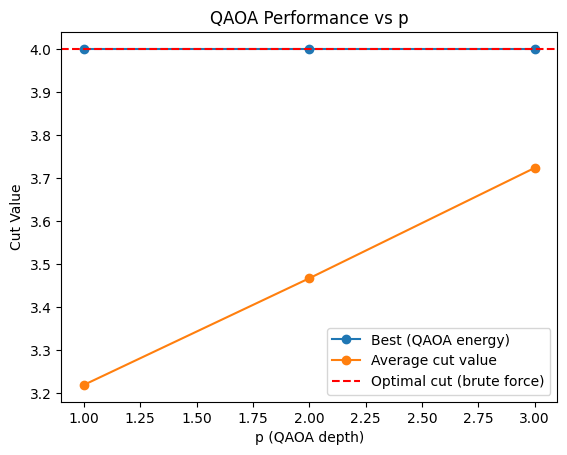

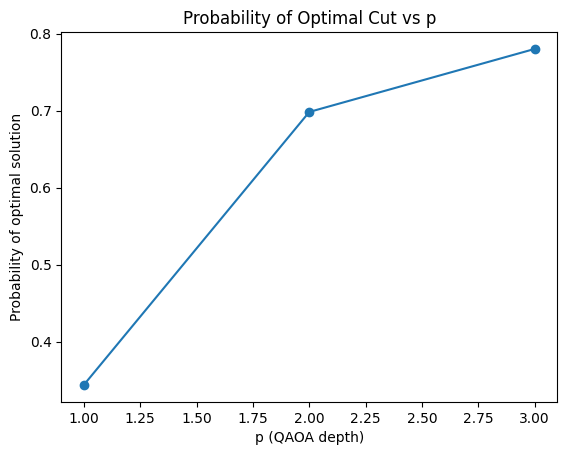

In [53]:
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# Returns expected energy of the QAOA state to be used in the scipy optimization
def get_energy(parameters, H_cost, H_mixer, p, n):
    gammas = parameters[:p]
    betas = parameters[p:]
    psi = qaoa_state(H_cost, H_mixer, gammas, betas)
    return expectation(psi, H_cost) 

# QAOA for Unweighted Max-Cut with varying p 
def run_experiment(adjacency_matrix, p_values):
    num_vertices = len(adjacency_matrix)
    H_cost = create_UW_hamiltonian(adjacency_matrix)
    H_mixer = create_mixer_hamiltonian(num_vertices)

    # find exact solution from brute force to compare against 
    optimal_x, optimal_cut = brute_force_maxcut(adjacency_matrix)

    best_cuts = []
    avg_cuts = []
    prob_optimal = []

    # iterate through different p values and optimize QAOA for each 
    for p in p_values:
        print(f"Running p={p}")

        # start off with random guess for gamma and beta parameters 
        init = np.random.rand(2*p)

        # finds the parameters that minimize the energy of the QAOA state 
        # using my optimization function 
        (gammas, betas), best_energy = optimize_qaoa(H_cost, H_mixer, p)

        # uncomment this to use scipy's optimization instead of mine - better resutls 
        #parameters = minimize(get_energy, init, args=(H_cost, H_mixer, p, n), method='Powell')
        #gammas = parameters.x[:p]
        #betas = parameters.x[p:]

        # builds the final state with the optimized parameters and calculates the probability distribution
        psi = qaoa_state(H_cost, H_mixer, gammas, betas)
        probabilities = np.abs(psi)**2

        values = []
        optimal_prob = 0
        max_cut = 0 

        # iterates over all bit strings to calculate their cut values and the probability of sampling the optimal solution
        for idx, bitstring in enumerate(itertools.product([0,1], repeat=num_vertices)):
            val = cut_value(bitstring, adjacency_matrix)
            values.append(val * probabilities[idx])

            if val == optimal_cut:
                optimal_prob += probabilities[idx]
                max_cut = val
    
        best_cuts.append(max_cut)
        avg_cuts.append(sum(values))
        prob_optimal.append(optimal_prob)

    return best_cuts, avg_cuts, prob_optimal, optimal_cut

# Main: Example run with the basic diamond graph
adj_basic = np.array([
        [0,1,1,0],
        [1,0,1,1],
        [1,1,0,1],
        [0,1,1,0]
    ])

p_values = [1,2,3] # tested p values 

best_cuts, avg_cuts, prob_optimal, optimal_cut = run_experiment(adj_basic, p_values)

# plot results 
plt.figure()
plt.plot(p_values, best_cuts, marker='o', label="Best (QAOA energy)")
plt.plot(p_values, avg_cuts, marker='o', label="Average cut value")
plt.axhline(optimal_cut, linestyle='--', color='red',label="Optimal cut (brute force)")
plt.xlabel("p (QAOA depth)")
plt.ylabel("Cut Value")
plt.legend()
plt.title("QAOA Performance vs p")
plt.show()

plt.figure()
plt.plot(p_values, prob_optimal, marker='o')
plt.xlabel("p (QAOA depth)")
plt.ylabel("Probability of optimal solution")
plt.title("Probability of Optimal Cut vs p")
plt.show()

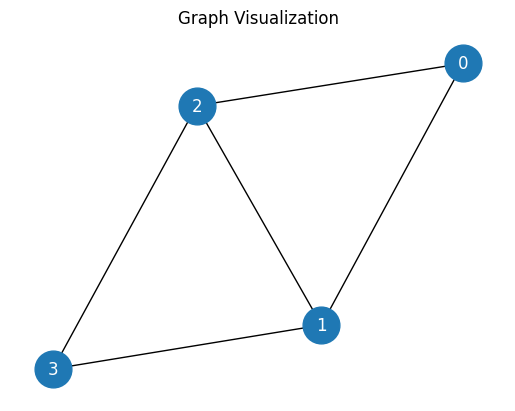

In [52]:
# Import visualization libraries 
import matplotlib.pyplot as plt
import networkx as nx

# Purpose: visualizes a given adjacency matrix as a graph 
# Input: adjacency matrix - 2D list with edges indicated as non-zero entries 
def visualize_graph(adjacency_matrix):
    # turns adjacency matrix into numpy array and gets number of vertices 
    adj = np.array(adjacency_matrix)
    n = len(adj)

    graph = nx.Graph() # intializes the graph object from the networkx library 

    # iterates through nodes and adds them to the graph 
    for i in range(n):
        graph.add_node(i)

    # iterates through edges and adds them to the graph with weights 
    for i in range(n):
        for j in range(i+1, n):
            if adj[i][j] != 0:
                graph.add_edge(i, j, weight=adj[i][j])

    # Layout (positions of nodes)
    positions = nx.spring_layout(graph, seed=42)

    # draw nodes, edges, and labels for the graph
    nx.draw_networkx_nodes(graph, positions, node_size=700)
    nx.draw_networkx_edges(graph, positions)
    nx.draw_networkx_labels(graph, positions, font_size=12, font_color="white")
    
    # if there's edge weights, draw them as labels on the edges 
    edge_labels = nx.get_edge_attributes(graph, 'weight')
    if set(edge_labels.values()) != {1}:
        nx.draw_networkx_edge_labels(graph, positions, edge_labels=edge_labels)

    plt.title("Graph Visualization")
    plt.axis('off')
    plt.show()

# Test Case Visualizations 

# Unweighted Max-Cut Examples: 
# diamond used 
adj_basic = [
    [0,1,1,0],
    [1,0,1,1],
    [1,1,0,1],
    [0,1,1,0]
]

# star
adj_star = [
    [0,1,1,1,1],
    [1,0,0,0,0],
    [1,0,0,0,0],
    [1,0,0,0,0],
    [1,0,0,0,0]
]

# line 
adj_line = [
    [0,1,0,0,1],
    [1,0,1,0,0],
    [0,1,0,0,0],
    [0,0,0,0,1],
    [1,0,0,1,0]
]

# square with cross inside
adj_square_cross = [
    [0,1,1,1],
    [1,0,1,1],
    [1,1,0,1],
    [1,1,1,0]
]

# Weighted Max-Cut Examples: 
# triangle + rectangle with varied weights
adj_weighted = [
    [0,2,0,1,0],
    [2,0,3,0,0],
    [0,3,0,4,1],
    [1,0,4,0,2],
    [0,0,1,2,0]
]

# varied weighted diamond
adj_diamond = [
    [0, 2, 0, 1],
    [2, 0, 3, 0],
    [0, 3, 0, 4],
    [1, 0, 4, 0]
]

# equal triangle with one heavy edge out 
adj_heavy_edge = [
    [0,10,0,0],
    [10,0,1,1],
    [0,1,0,1],
    [0,1,1,0]
]

visualize_graph(adj_basic)

